# PPE Detection — Training Model YOLO11s

Notebook ini melatih model deteksi **Alat Pelindung Diri (APD)** pada citra lokasi kerja konstruksi.

| Item | Nilai |
|------|-------|
| Base model | `yolo11s.pt` (pretrained, transfer learning) |
| Kelas | **helmet, vest** (2 kelas) |
| Epoch | 100 |
| Image size | 640 × 640 |
| Batch | 16 |
| Dataset | Roboflow *ppe-detection-yolo* v3 |

**Cara pakai:** jalankan cell berurutan dari atas ke bawah.

## 1. Setup

Import library dan tentukan lokasi `data.yaml`. Variabel `KMP_DUPLICATE_LIB_OK` mencegah crash konflik OpenMP yang umum di lingkungan Anaconda pada Windows.

In [8]:
import os, glob, shutil
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # cegah crash konflik OpenMP (Anaconda/Windows)

from ultralytics import YOLO
from IPython.display import Image, display

# path data.yaml (dataset 2 kelas: helmet, vest) relatif ke folder training/
DATA = os.path.abspath(os.path.join(os.getcwd(), "..", "dataset_2class", "data.yaml"))
print("data.yaml :", DATA)
print("ditemukan :", os.path.exists(DATA))

data.yaml : c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\data.yaml
ditemukan : True


## 2. Training

Melatih `yolo11s.pt` selama 100 epoch pada resolusi 640.

> **Jika muncul `CUDA out of memory`** (VRAM kecil, mis. 4 GB): turunkan `batch` jadi `8` atau `4`.

In [9]:
model = YOLO("yolo11s.pt")

results = model.train(
    data=DATA,
    epochs=100,
    imgsz=640,
    batch=16,       # OOM? turunkan ke 8 atau 4
    device=0,       # GPU; ganti 'cpu' bila tak ada GPU
    patience=15,    # early stop bila 15 epoch tak membaik
    workers=0,      # Windows: hindari crash multiprocessing
)

RUN_DIR = str(results.save_dir)  # folder output, mis. runs/detect/train
print("\nHasil training tersimpan di:", RUN_DIR)

Ultralytics 8.4.68  Python-3.13.5 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=Fal

## 3. Evaluasi Akurasi

Validasi model dan tampilkan metrik utama: **Precision, Recall, mAP@0.5, mAP@0.5:0.95**, beserta rincian per kelas (memakai `class_result` agar mAP@0.5 per kelas akurat).

In [11]:
metrics = model.val(data=DATA, imgsz=640, workers=0)

print("=== RINGKASAN AKURASI ===")
print(f"Precision    : {metrics.box.mp:.3f}")
print(f"Recall       : {metrics.box.mr:.3f}")
print(f"mAP@0.5      : {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.3f}")
print("\nPer kelas:")
print(f"  {'kelas':8s} {'P':>6s} {'R':>6s} {'mAP50':>7s} {'mAP50-95':>9s}")
for idx, i in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(idx)
    print(f"  {model.names[i]:8s} {p:6.3f} {r:6.3f} {ap50:7.3f} {ap:9.3f}")

Ultralytics 8.4.68  Python-3.13.5 torch-2.12.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 673.7216.0 MB/s, size: 58.8 KB)
val: Scanning C:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\valid\labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.7it/s 0.6s
                   all         15         40      0.961       0.89      0.917      0.743
                helmet         12         13          1      0.896      0.925      0.815
                  vest         15         27      0.923      0.884       0.91      0.671
Speed: 4.2ms preprocess, 26.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\training\runs\detect\val-7
=== RINGKASAN AKURASI ===
Precision    : 0.96

## 4. Grafik Training

Kurva *loss* (box / cls / dfl) dan metrik (precision, recall, mAP) sepanjang epoch. Loss menurun dan mAP menanjak menandakan training berjalan baik.

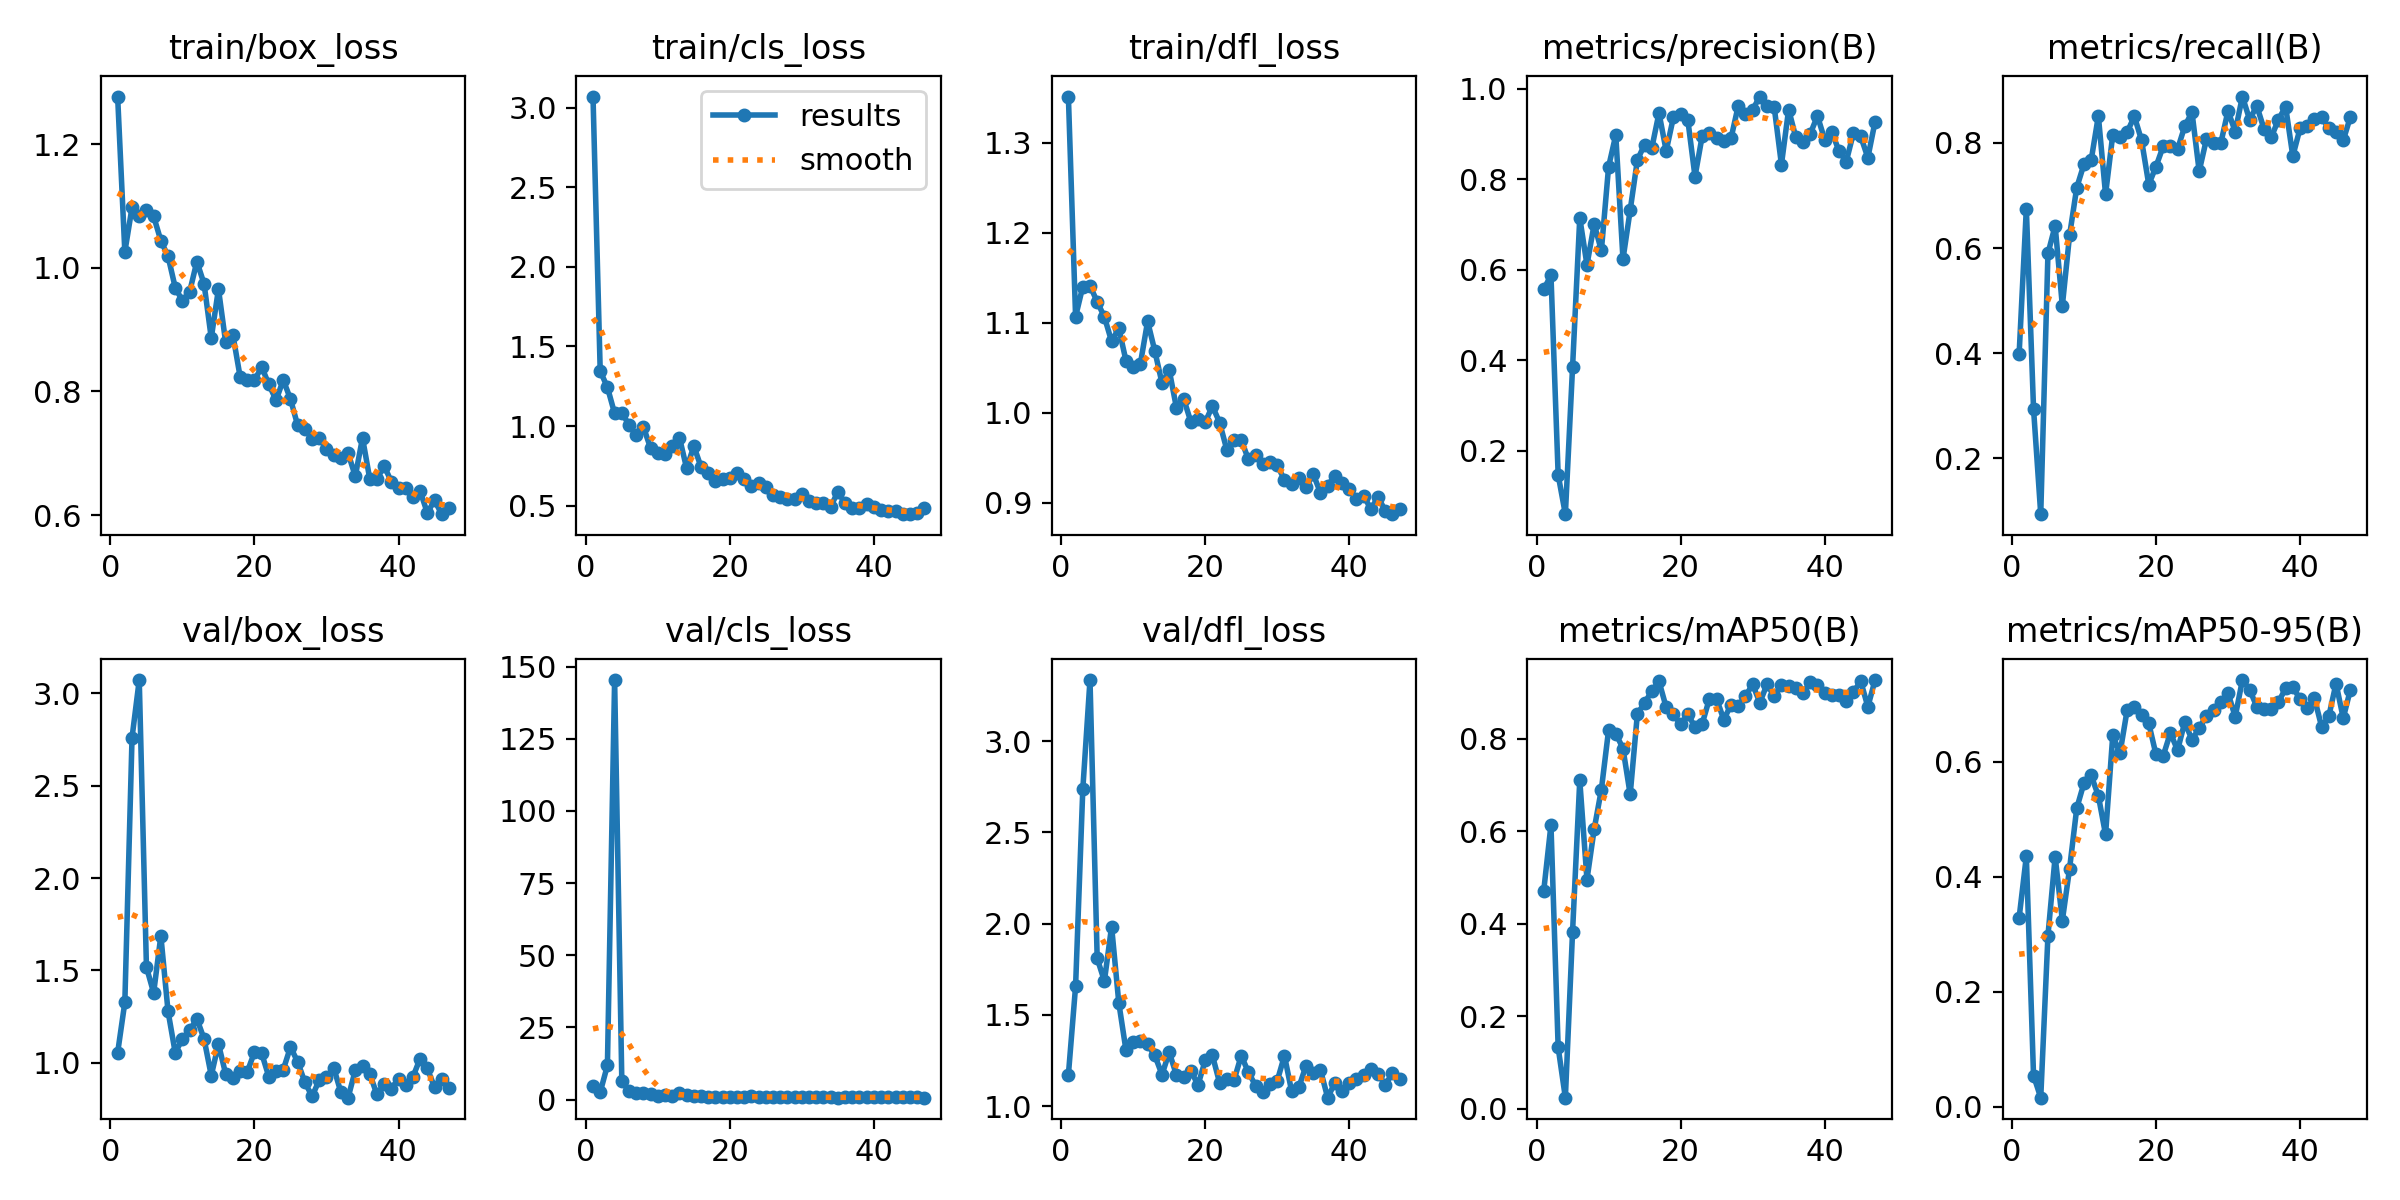

In [12]:
display(Image(filename=os.path.join(RUN_DIR, "results.png")))

## 5. Confusion Matrix

Matriks kebingungan: seberapa sering tiap kelas diprediksi benar vs tertukar (termasuk dengan *background*). Versi *normalized* menampilkan proporsi (0–1).

confusion_matrix.png


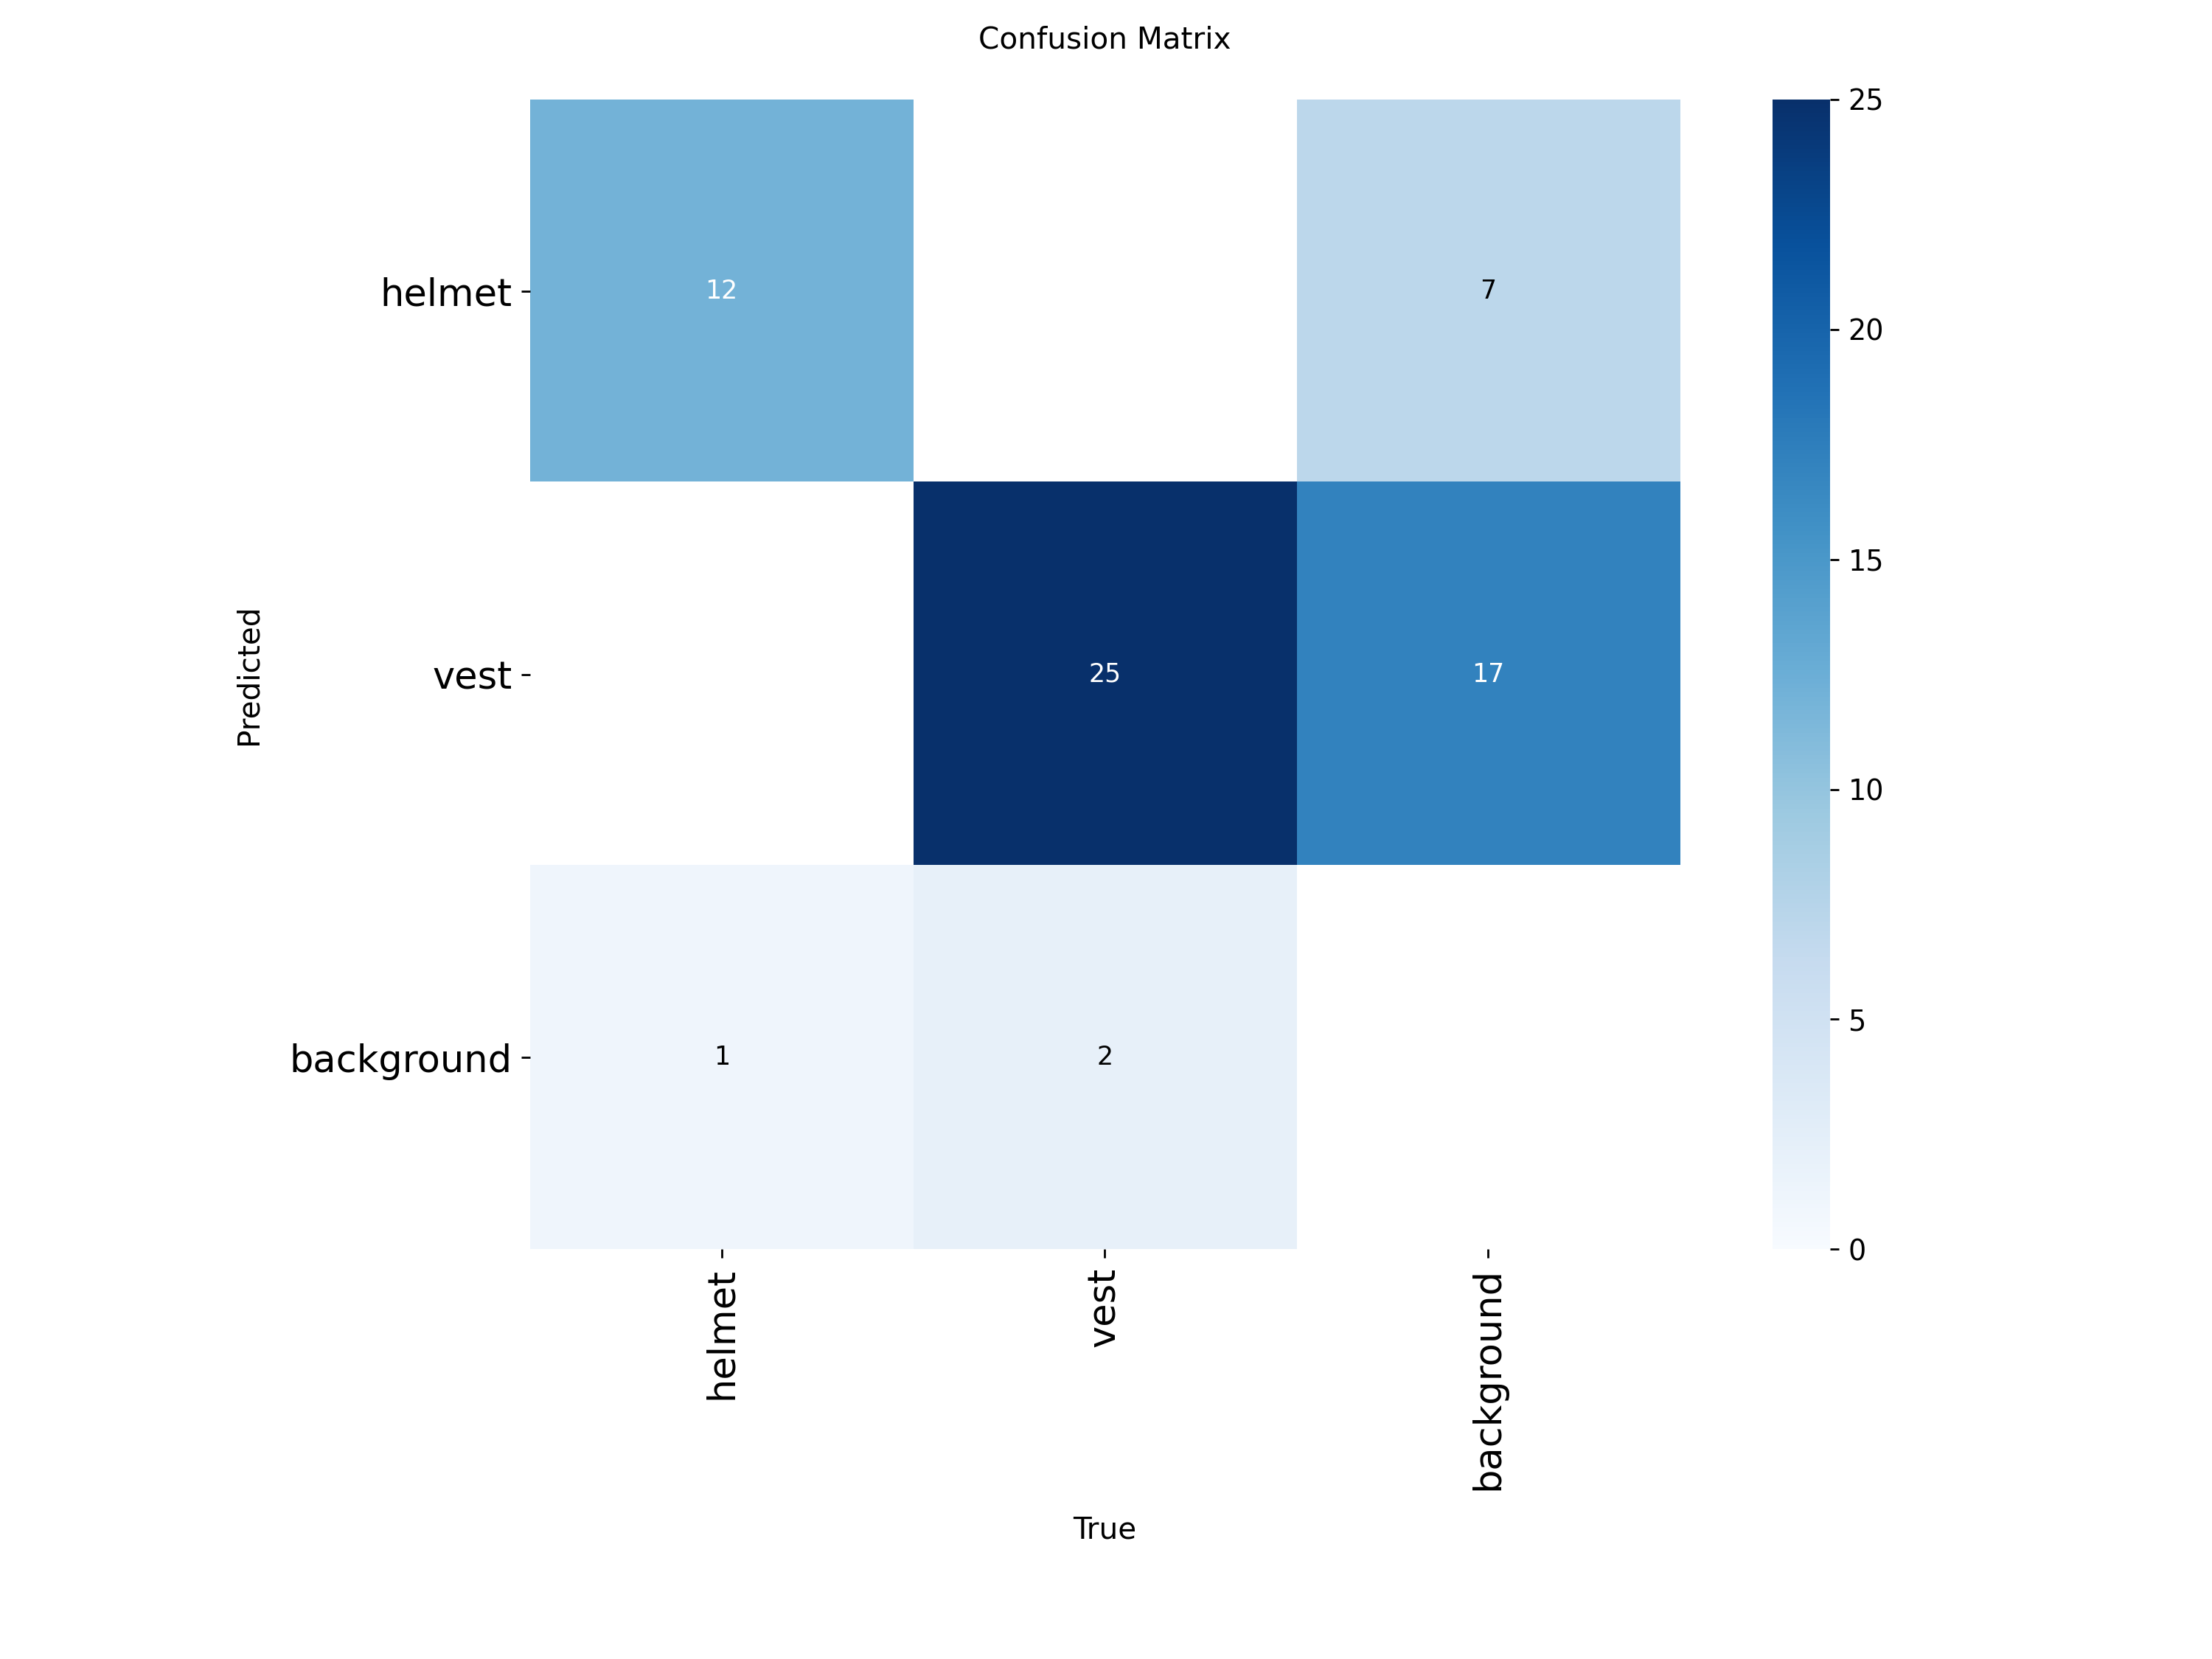

confusion_matrix_normalized.png


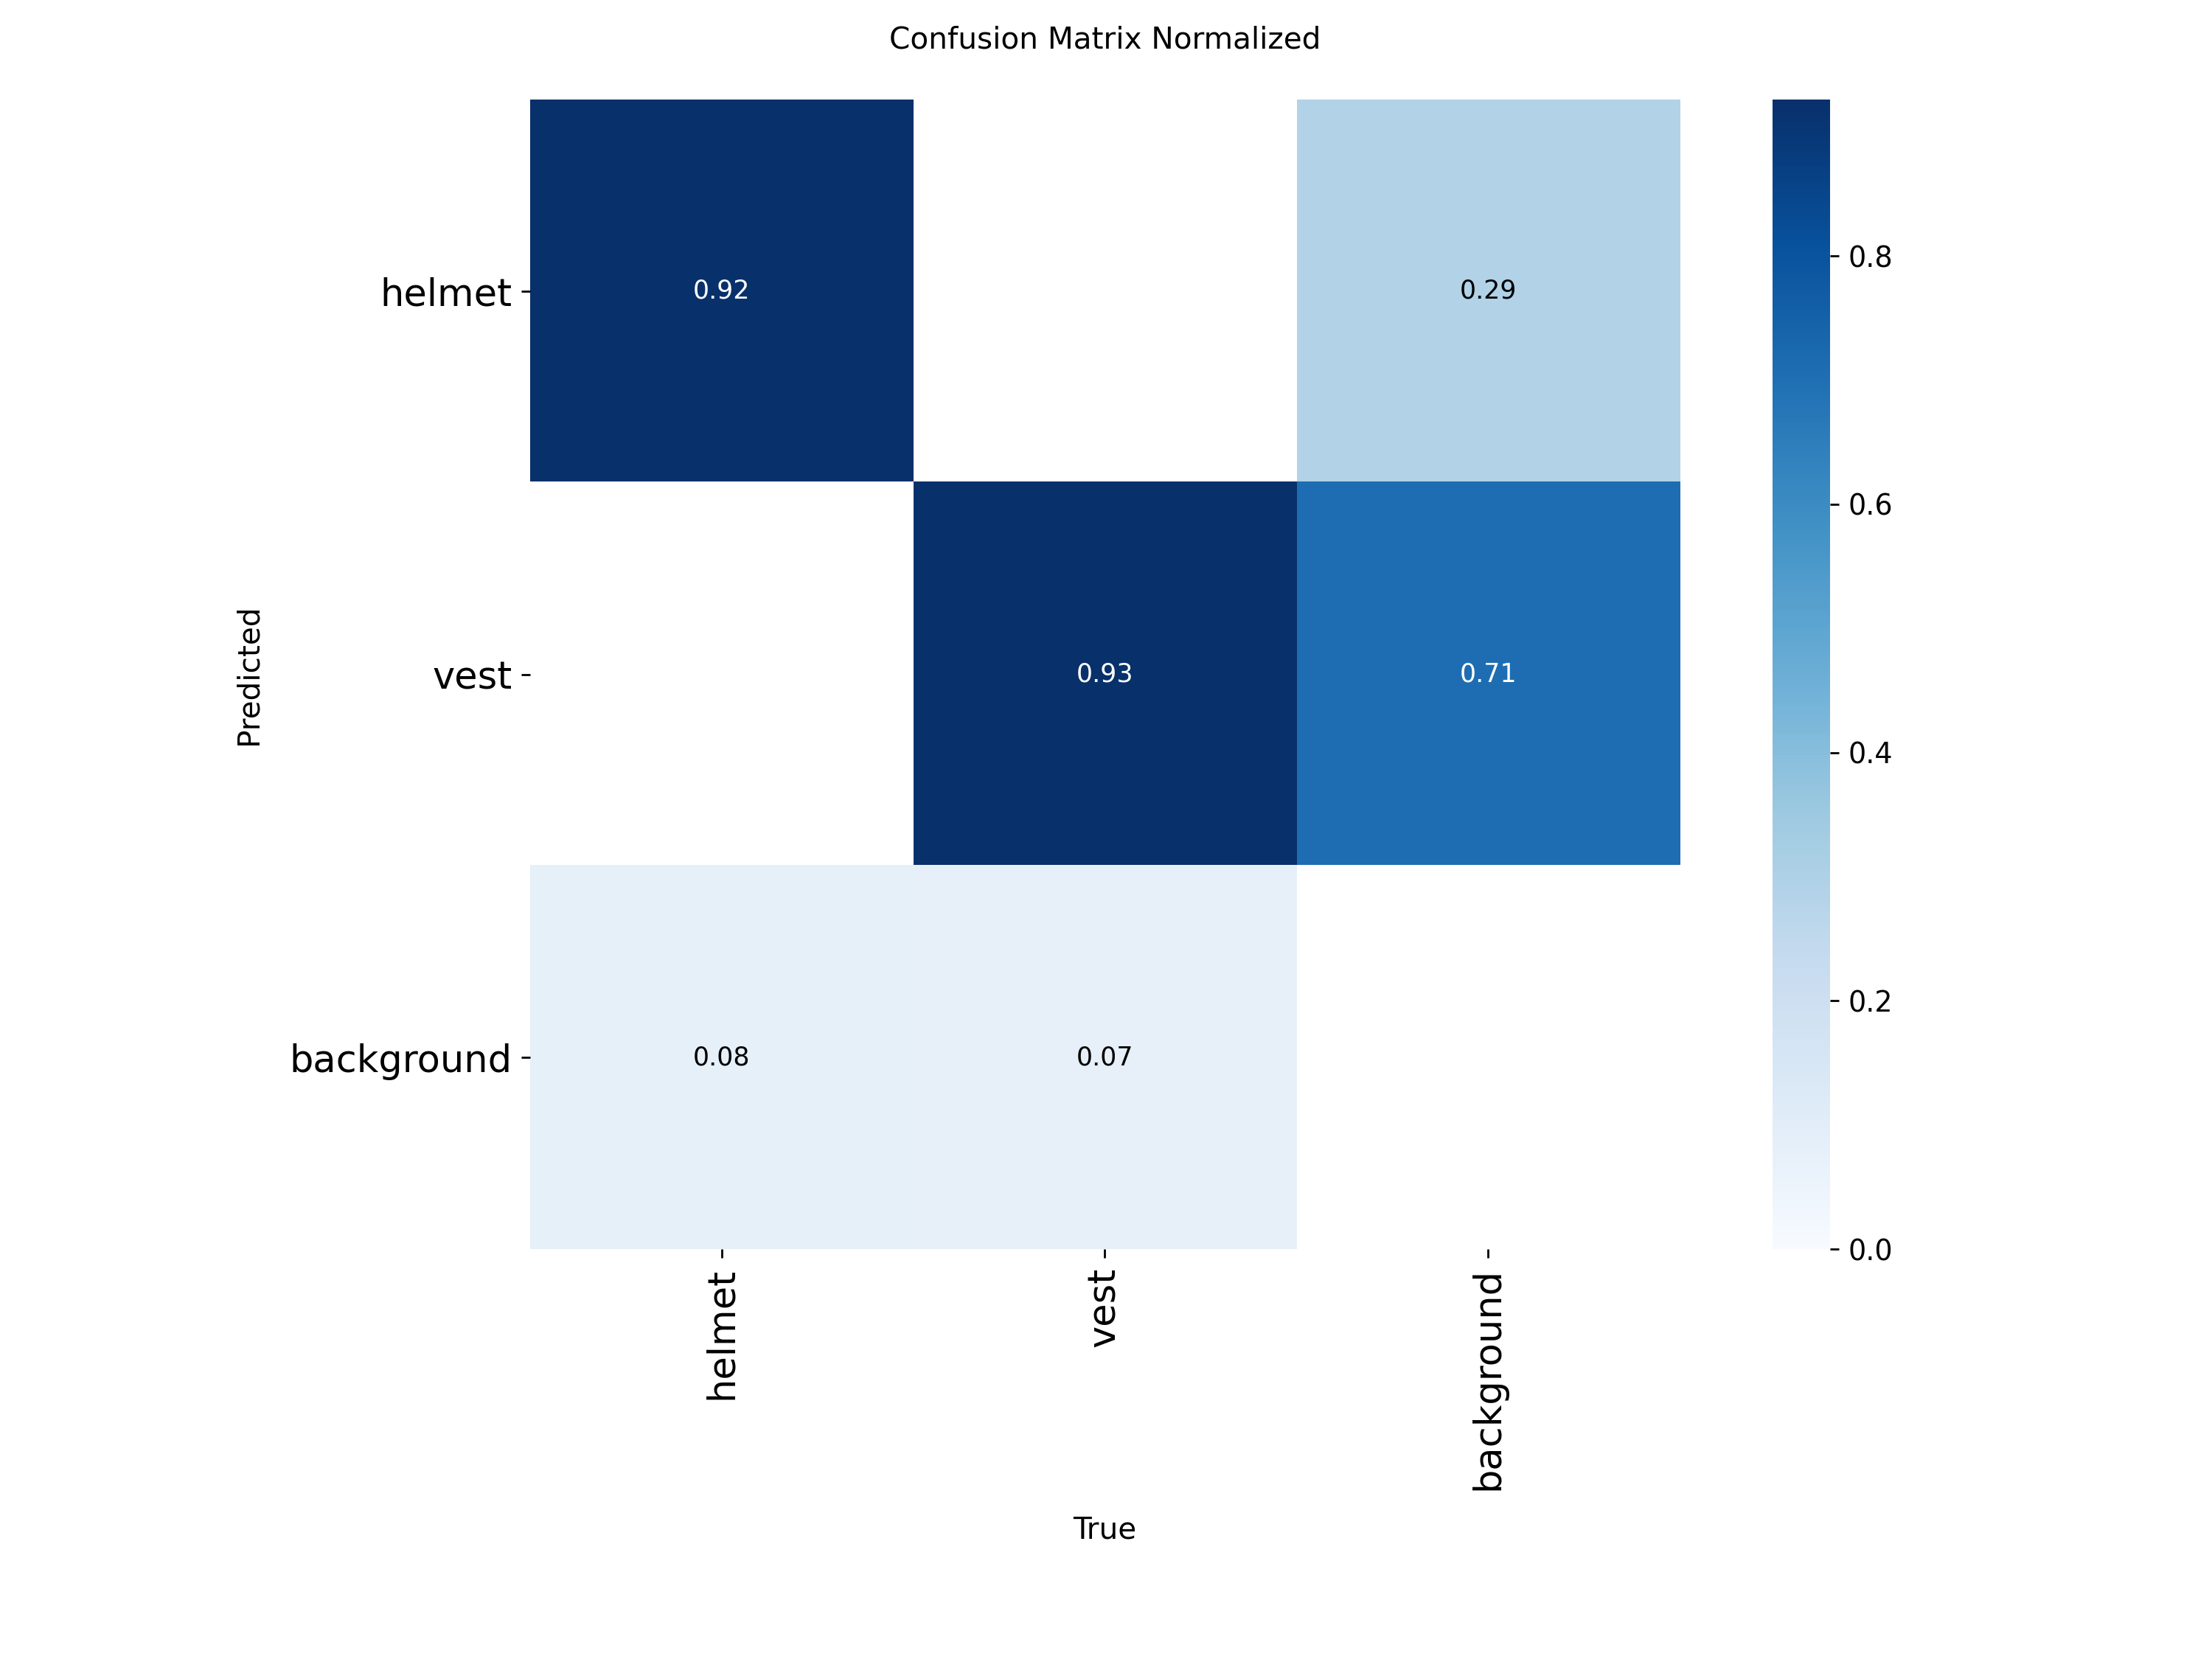

In [13]:
for f in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
    p = os.path.join(RUN_DIR, f)
    if os.path.exists(p):
        print(f)
        display(Image(filename=p))

## 6. Kurva F1 / Precision / Recall / PR

- **F1-curve**: F1 terhadap *confidence threshold* (cari titik puncak).
- **P-curve / R-curve**: precision & recall terhadap threshold.
- **PR-curve**: precision vs recall; luas area = mAP. Makin menempel pojok kanan-atas makin baik.

BoxF1_curve.png


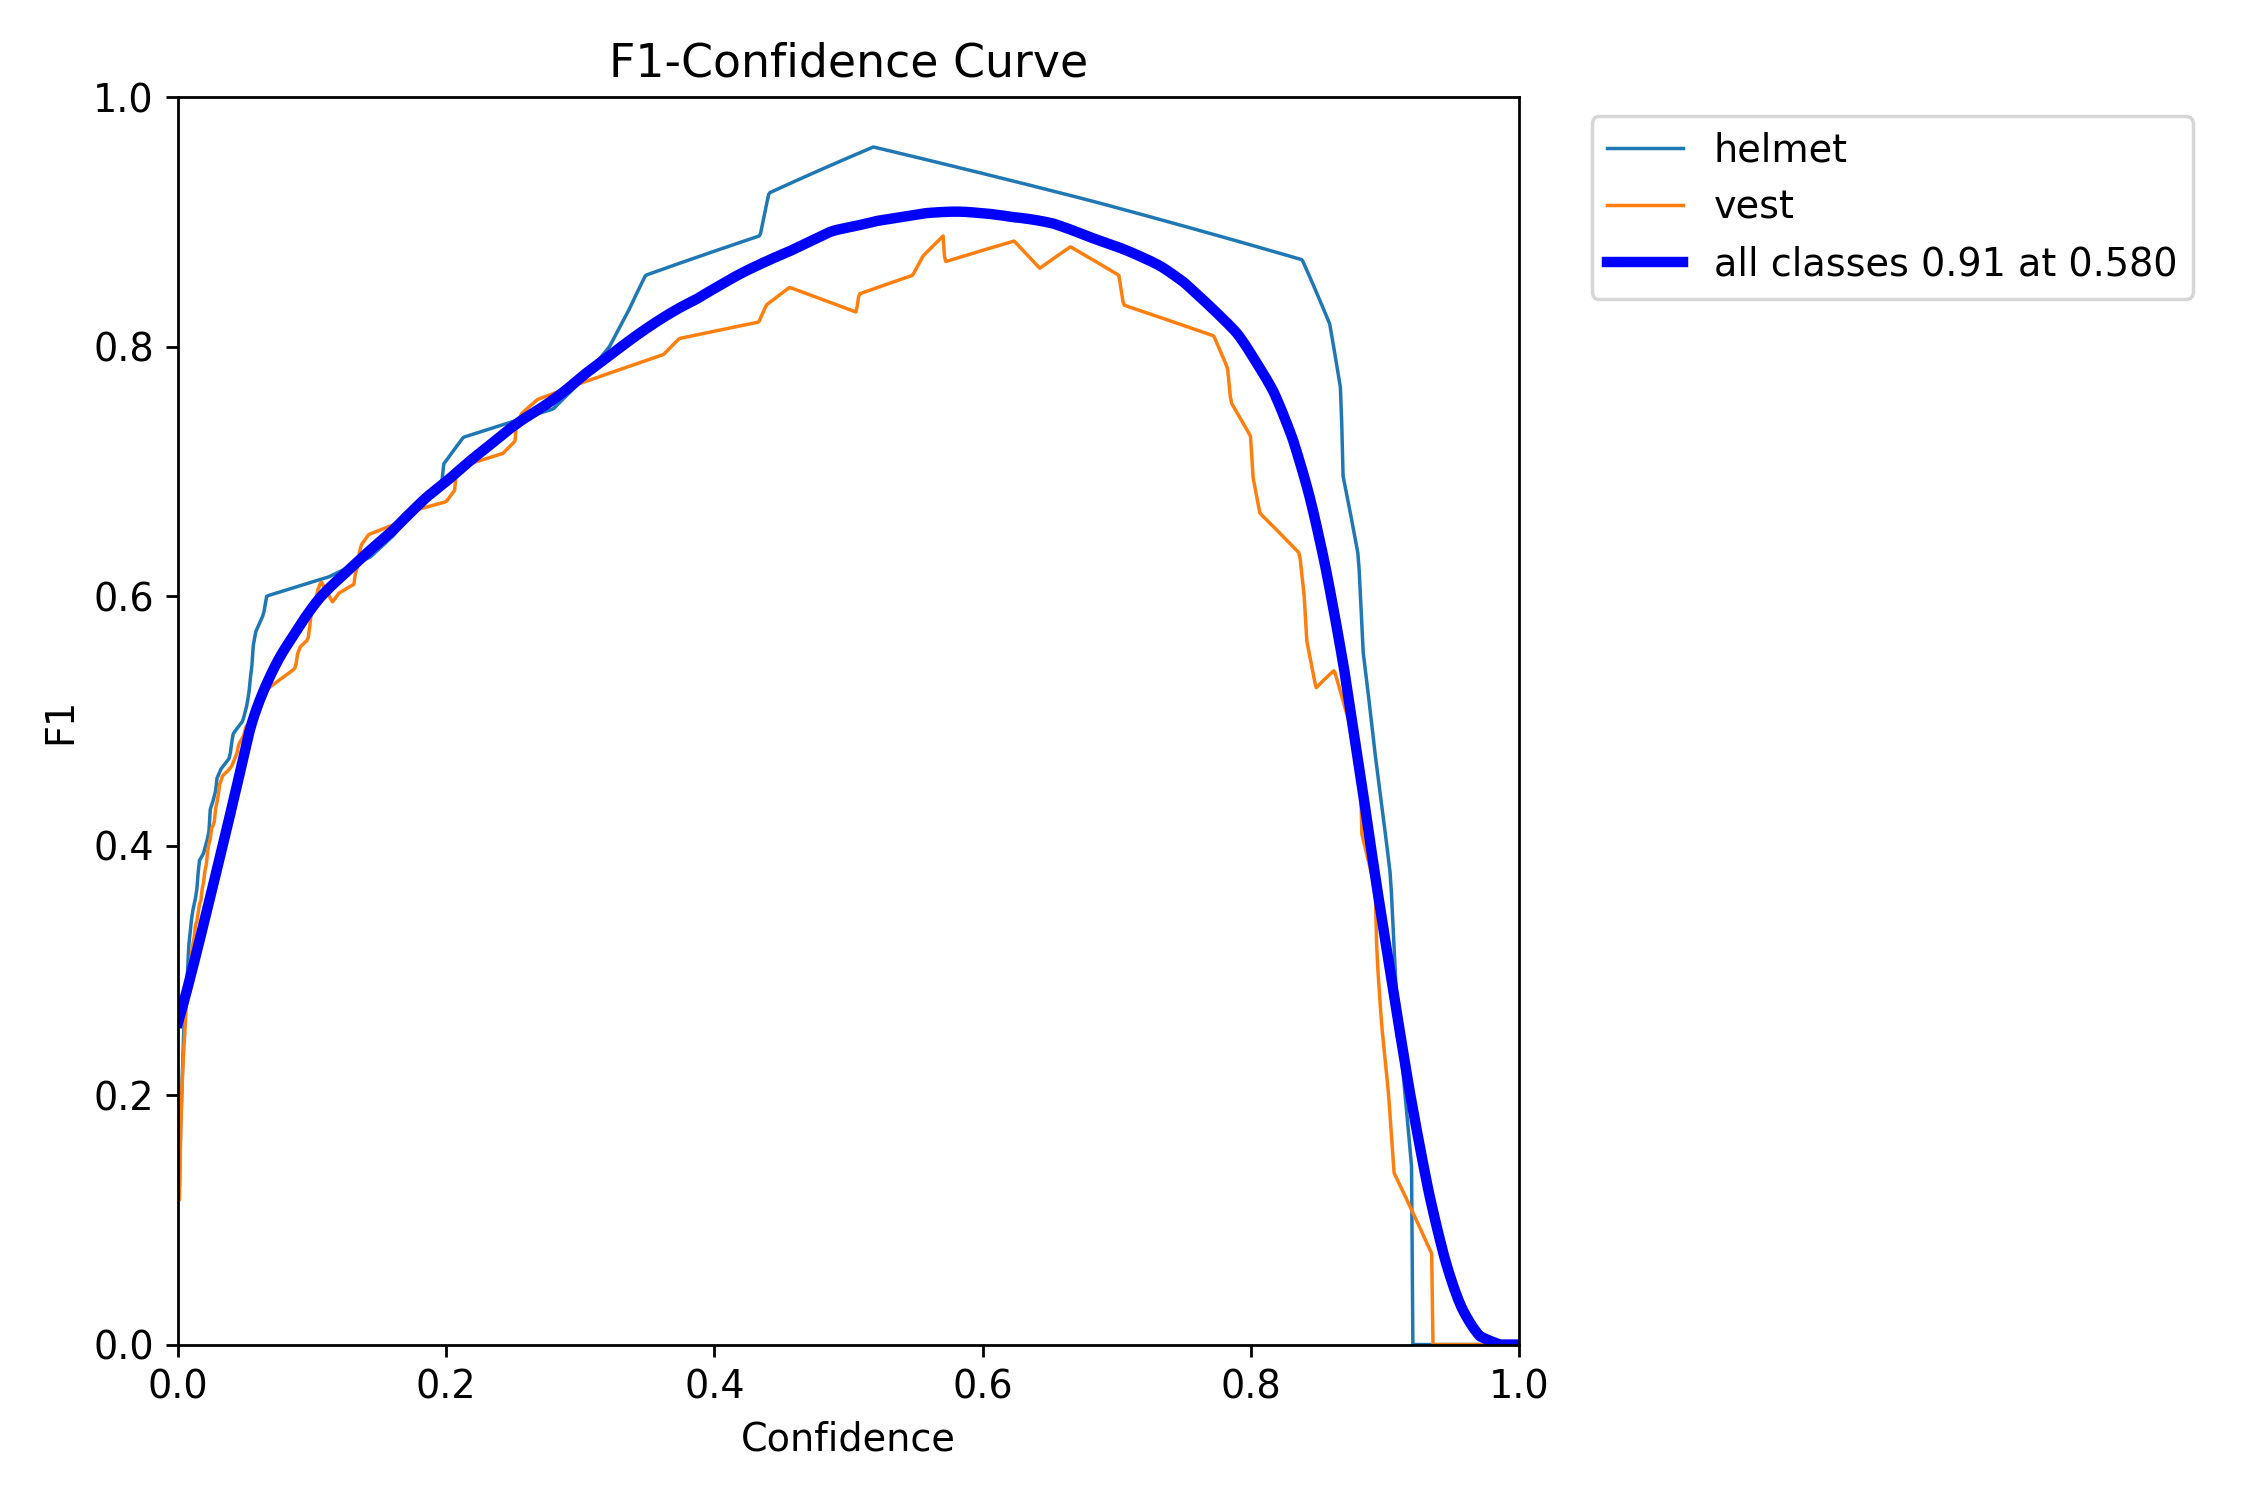

BoxPR_curve.png


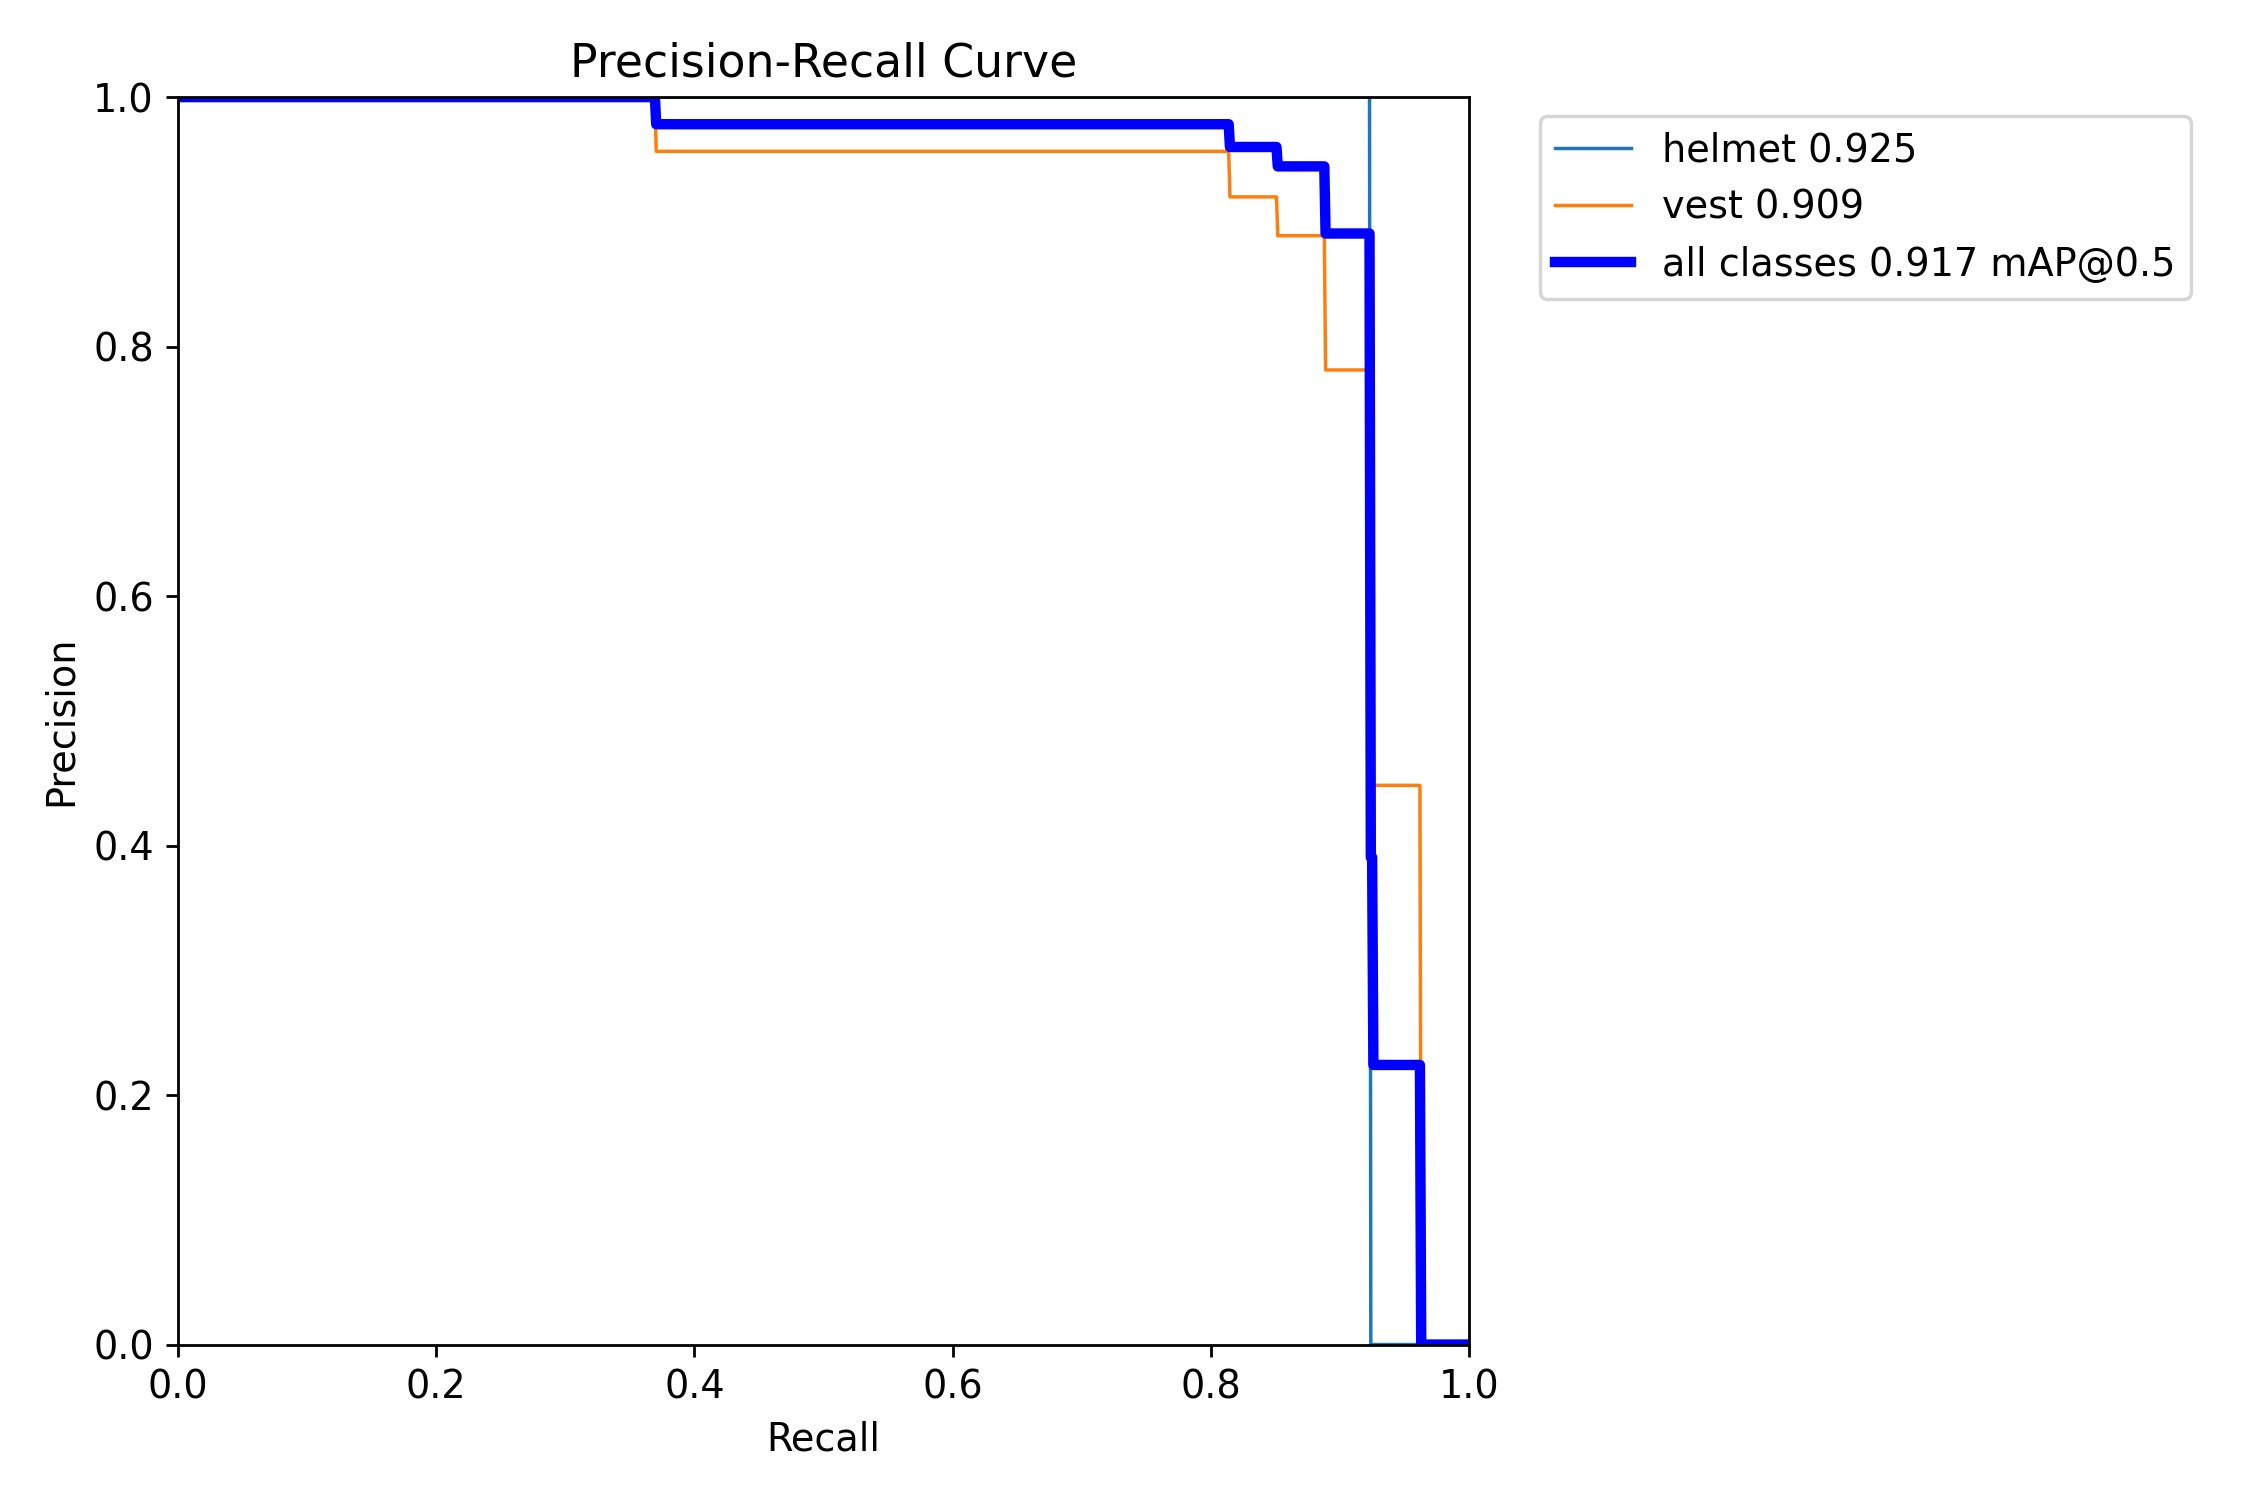

In [14]:
for f in ["F1_curve.png", "P_curve.png", "R_curve.png", "PR_curve.png",
          "BoxF1_curve.png", "BoxPR_curve.png"]:
    p = os.path.join(RUN_DIR, f)
    if os.path.exists(p):
        print(f)
        display(Image(filename=p))

## 7. Contoh Prediksi (validation batch)

Visualisasi *bounding box* hasil model pada batch data validasi — bukti kualitatif performa deteksi.

val_batch0_pred.jpg


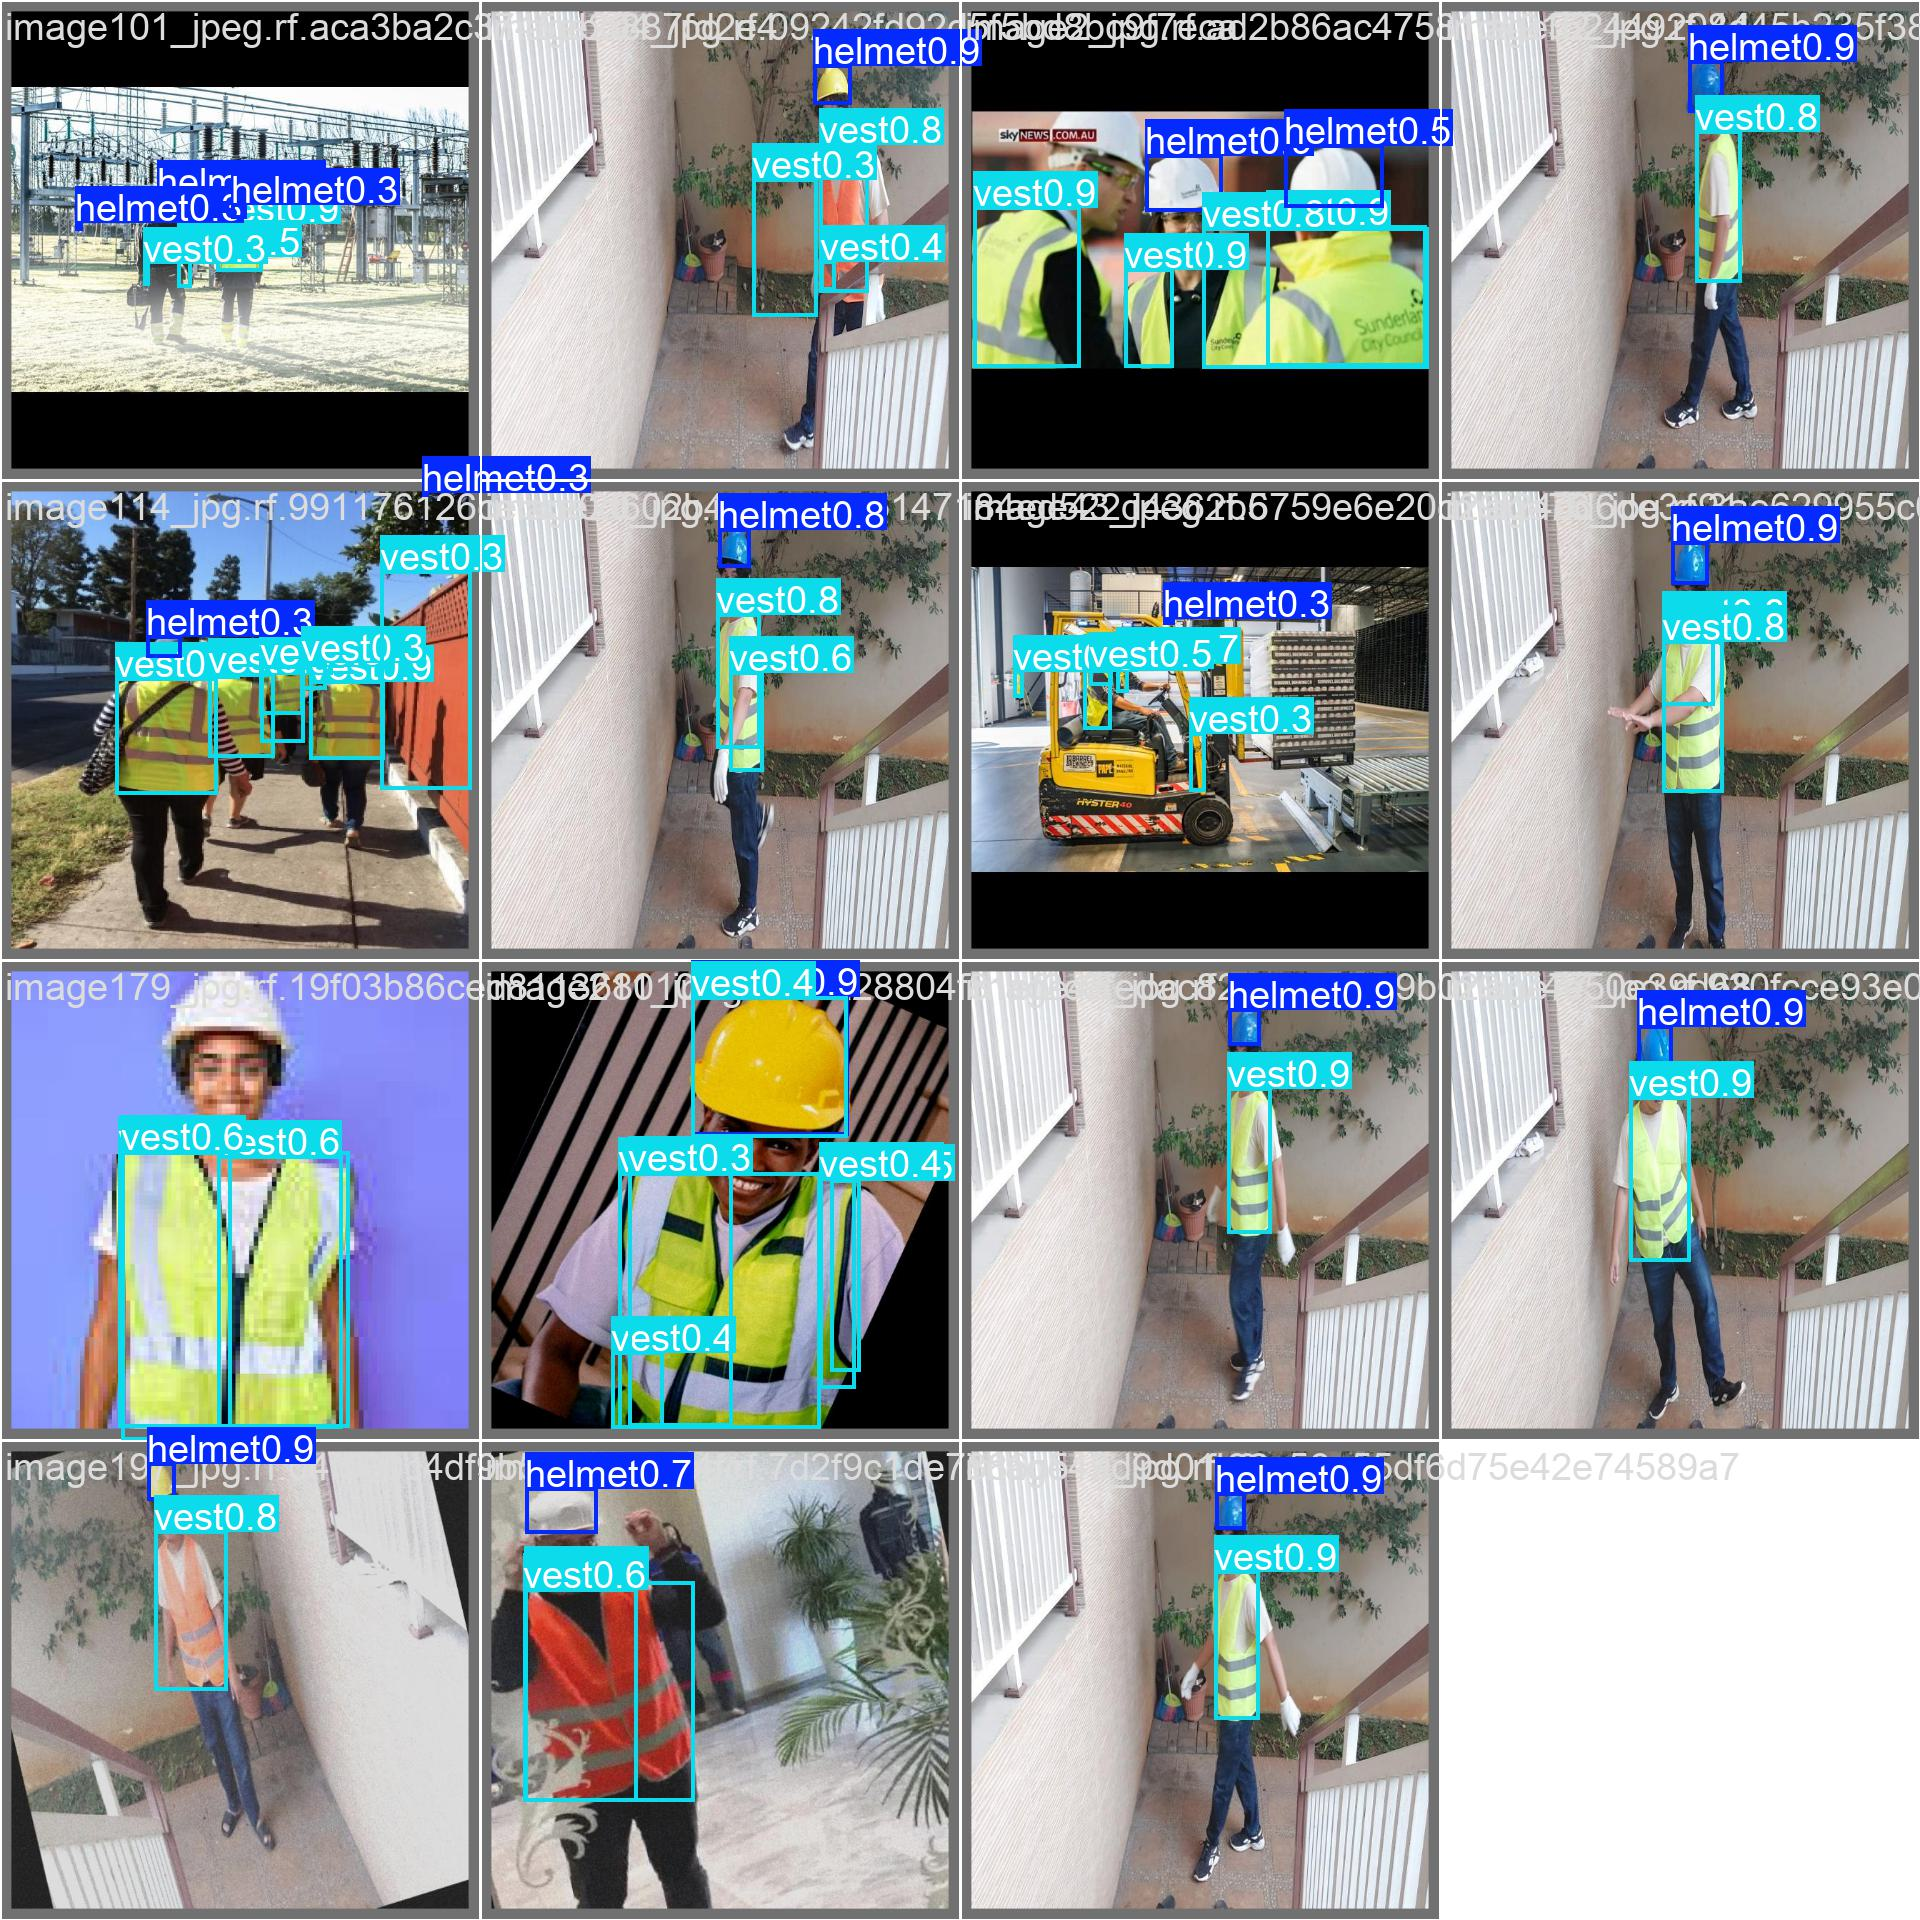

In [15]:
for p in sorted(glob.glob(os.path.join(RUN_DIR, "val_batch*_pred.jpg"))):
    print(os.path.basename(p))
    display(Image(filename=p))

## 8. Uji Gambar (opsional)

Deteksi pada folder/gambar uji. Ubah `image_file` ke path gambarmu sendiri bila perlu.


image 1/16 c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\test\images\image102_jpg.rf.64334401eb5ea147210bfe3966ccf7aa.jpg: 640x640 1 helmet, 2 vests, 110.7ms
image 2/16 c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\test\images\image126_jpg.rf.33b4e16c57e143bb8ec3764795bc7744.jpg: 640x640 5 helmets, 6 vests, 11.5ms
image 3/16 c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\test\images\image133_jpeg.rf.2074ec211940ab0275139a0a26186d3e.jpg: 640x640 1 helmet, 1 vest, 11.5ms
image 4/16 c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\test\images\image188_jpg.rf.3e5628d275e50623c48bb190b6d09dc9.jpg: 640x640 3 helmets, 3 vests, 14.5ms
image 5/16 c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\dataset_2class\test\images\image189_jpg.rf.a6e6de0dd8d41d89e30aea038153230b.jpg: 640x640 2 helmets, 4 vests, 11.7ms
image 6/16 c:\Users\ASUS\Documents\Semester 6\Computer 

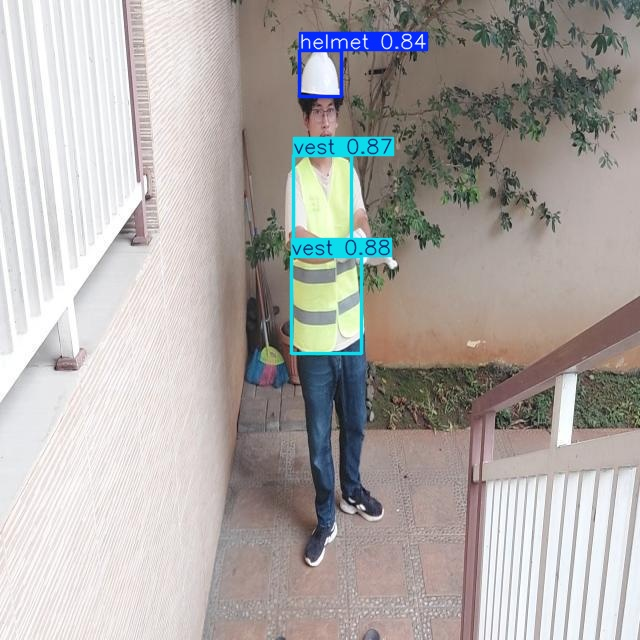

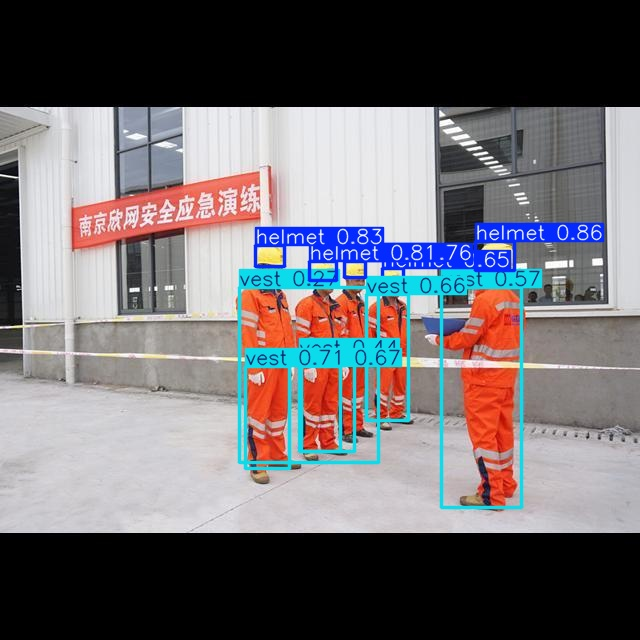

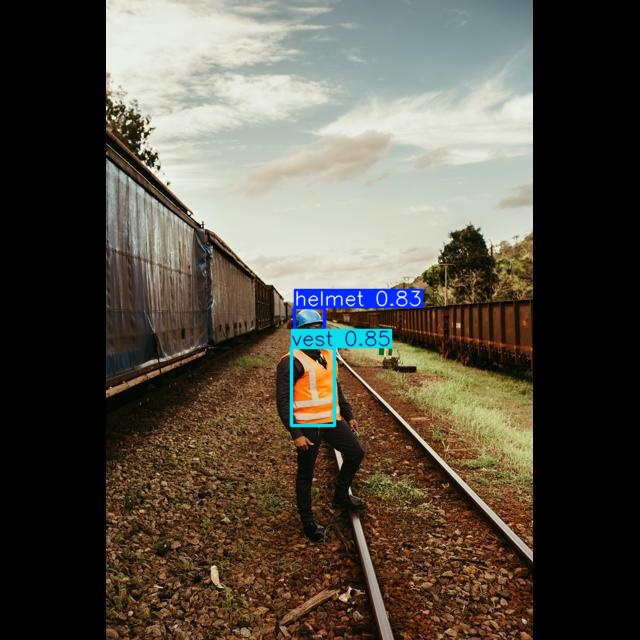

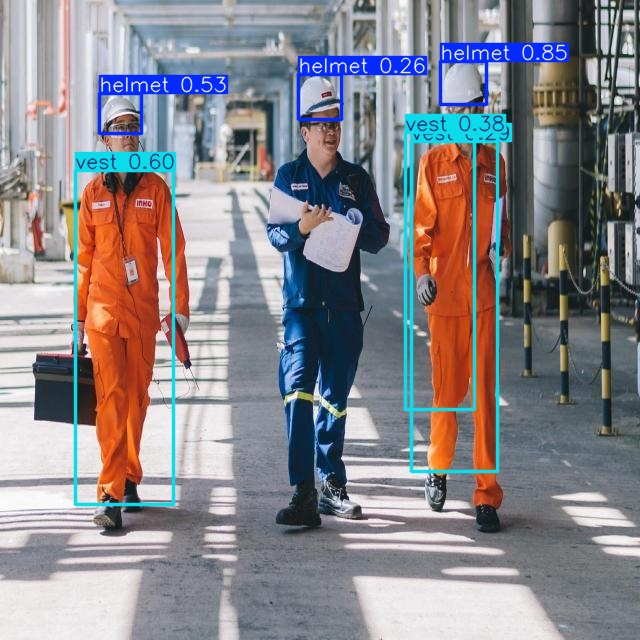

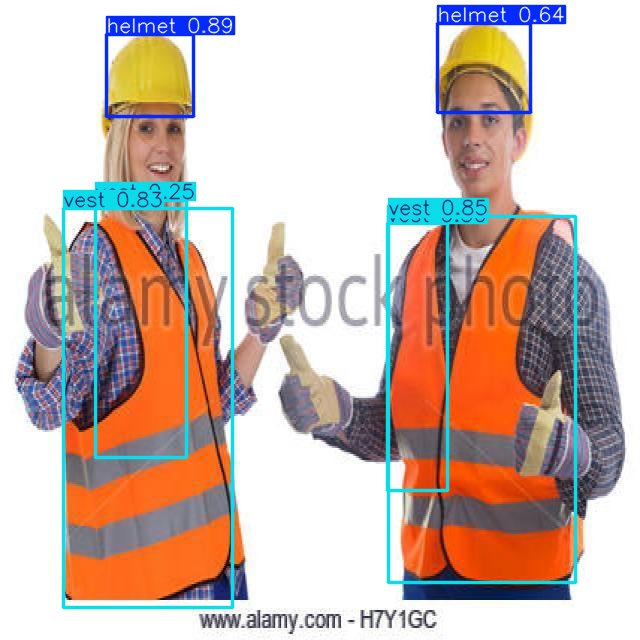

In [16]:
image_file = os.path.abspath(os.path.join(os.getcwd(), "..", "dataset_2class", "test", "images"))

pred = model.predict(source=image_file, conf=0.25, save=True)
out_dir = str(pred[0].save_dir)
print("Hasil disimpan di:", out_dir)
for p in sorted(glob.glob(os.path.join(out_dir, "*.jpg")))[:5]:
    display(Image(filename=p))

## 9. Simpan Model

Salin bobot terbaik ke `training/best_new.pt`. Diberi nama berbeda agar **tidak menimpa** `app/best.pt` yang dipakai aplikasi. Grafik & `results.csv` tetap di `RUN_DIR`.

In [17]:
dst = os.path.abspath(os.path.join(os.getcwd(), "best_new.pt"))
shutil.copy(os.path.join(RUN_DIR, "weights", "best.pt"), dst)
print("Model tersimpan :", dst)
print("Grafik & metrik :", RUN_DIR)

Model tersimpan : c:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\training\best_new.pt
Grafik & metrik : C:\Users\ASUS\Documents\Semester 6\Computer Vision\Projek_uas\training\runs\detect\train-2
